# HW1 Part I Local Data Exploration

Use this notebook for the report's first part: visualize the filtered CelebA subset, inspect tensor shape/range, and collect observations for `questions/part_i.tex`.

This notebook is intended for local development. The Colab notebook should stay focused on later GPU training.

## 0. Work From Repository Root

If this notebook is opened from the `HW1_CMU_10799_Spring_2026/` folder, run the next cell once to move to the repository root.

In [4]:
from pathlib import Path
import os

cwd = Path.cwd()
if cwd.name == "HW1_CMU_10799_Spring_2026":
    os.chdir(cwd.parent)

print(Path.cwd())

/Users/eric/courses/cmu-10799-diffusion


## 1. Download Local Dataset If Needed

The expected local layout is `data/celeba-subset/train/images/`. Run the next cell if that folder does not exist yet.

In [5]:
!python download_dataset.py --output_dir ./data/celeba-subset --split all

Repository: electronickale/cmu-10799-celeba64-subset
Output: ./data/celeba-subset
Split: all

README.md: 2.36kB [00:00, 1.43MB/s]
data/train-00000-of-00001.parquet: 100%|█████| 471M/471M [00:29<00:00, 15.8MB/s]
Generating train split: 100%|███| 63715/63715 [00:00<00:00, 96515.38 examples/s]

Saving 63715 images to data/celeba-subset/train...
Saving train: 100%|█████████████████████| 63715/63715 [00:52<00:00, 1219.63it/s]
Saved attributes: ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald']...

Download complete!

Dataset saved to: data/celeba-subset

To use in training:
  python train.py --method ddpm --config configs/ddpm.yaml

  (Make sure data.root in config points to data/celeba-subset)


## 2. Verify Local Dataset

In [6]:
from pathlib import Path

data_root = Path("data/celeba-subset")
train_images = data_root / "train" / "images"

print("data_root exists:", data_root.exists())
print("train_images exists:", train_images.exists())
if train_images.exists():
    image_paths = sorted(train_images.glob("*.png")) or sorted(train_images.glob("*.jpg"))
    print("num train images:", len(image_paths))
    print("first image:", image_paths[0] if image_paths else "none")

data_root exists: True
train_images exists: True
num train images: 63715
first image: data/celeba-subset/train/images/000002.png


## 3. Inspect Dataset Tensor Contract

For DDPM training, each clean image `x_0` should be a `(3, 64, 64)` float tensor in `[-1, 1]`.

In [7]:
import torch

from src.data import CelebADataset

dataset = CelebADataset(
    root="./data/celeba-subset",
    split="train",
    image_size=64,
    augment=False,
    from_hub=False,
)

x_0 = dataset[0]
print("dataset size:", len(dataset))
print("shape:", tuple(x_0.shape))
print("dtype:", x_0.dtype)
print("range:", float(x_0.min()), float(x_0.max()))
print("finite:", bool(torch.isfinite(x_0).all()))

Loaded 63715 images from local directory
dataset size: 63715
shape: (3, 64, 64)
dtype: torch.float32
range: -1.0 0.9686274528503418
finite: True


## 4. Generate Part I Sample Grid

This creates the 16-image grid required by Part I and writes it into the HW1 figures folder.

In [9]:
!python scripts/make_celeba_grid.py \
  --root ./data/celeba-subset \
  --split train \
  --output HW1_CMU_10799_Spring_2026/figures/part_i_samples.png \
  --num-samples 16 \
  --seed 42

Loaded 63715 images from local directory
Saved 16 samples to HW1_CMU_10799_Spring_2026/figures/part_i_samples.png
Tensor shape: (16, 3, 64, 64)
Tensor range: [-1.000, 1.000]


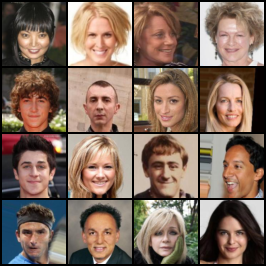

In [10]:
from IPython.display import Image, display

display(Image("HW1_CMU_10799_Spring_2026/figures/part_i_samples.png"))

## 5. Notes For The Report

After looking at the grid, write short observations here before transferring them into `questions/part_i.tex`.

- Visible common attributes:
- Attributes that seem rare or filtered out:
- Augmentation choice and rationale:
- Why full-CelebA SOTA may not remain SOTA on this filtered subset: